In [ ]:
! pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found ex

In [ ]:
import snowflake.connector
conn = snowflake.connector.connect(
    user='RACHITH',
    password='RachithVenkatesh_118',
    account='BBPVRKO-GW15734',
    database='SAMPLE_DATABASE',
    schema='PUBLIC',
    werehouse='COMPUTE_WH'
)

In [ ]:
query='SELECT * FROM "BANK_TRANS" '

In [ ]:
import pandas as pd

df=pd.read_sql(query,conn)
conn.close()
print(df.head())

/tmp/ipykernel_4086/3483741725.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


   TRANSACTION_ID  TRANSACTION_AMOUNT  LOGIN_ATTEMPTS  DEVICE_RISK_SCORE  \
0         1000001            17829.01               4               12.0   
1         1000002            16401.83               1               34.3   
2         1000003             9678.29               8               67.8   
3         1000004            19013.38               5               17.8   
4         1000005            13834.95               3               88.9   

   TRANSFER_FREQUENCY  ANOMALY_SCORE  ACCOUNT_AGE_DAYS  TRANSACTION_TIME_HOUR  \
0                  13           0.37              2354                     22   
1                  17           0.26              3181                     17   
2                  39           0.15              1390                      3   
3                  42           0.55              3716                     16   
4                  63           0.24              4694                     16   

   FAILED_TRANSACTIONS_LAST_30D  AVG_MONTHLY_BALANCE  DA

In [ ]:
df.shape

(10000, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   TRANSACTION_ID                  10000 non-null  int64  
 1   TRANSACTION_AMOUNT              10000 non-null  float64
 2   LOGIN_ATTEMPTS                  10000 non-null  int64  
 3   DEVICE_RISK_SCORE               10000 non-null  float64
 4   TRANSFER_FREQUENCY              10000 non-null  int64  
 5   ANOMALY_SCORE                   10000 non-null  float64
 6   ACCOUNT_AGE_DAYS                10000 non-null  int64  
 7   TRANSACTION_TIME_HOUR           10000 non-null  int64  
 8   FAILED_TRANSACTIONS_LAST_30D    10000 non-null  int64  
 9   AVG_MONTHLY_BALANCE             10000 non-null  float64
 10  DAILY_TRANSACTION_COUNT         10000 non-null  int64  
 11  GEO_DISTANCE_KM                 10000 non-null  int64  
 12  SESSION_DURATION_MINUTES        1

In [ ]:
df = pd.get_dummies(df,columns=["PAYMENT_CHANNEL", "AUTHENTICATION_TYPE"], drop_first=True)


In [ ]:
df

,TRANSACTION_ID,TRANSACTION_AMOUNT,LOGIN_ATTEMPTS,DEVICE_RISK_SCORE,TRANSFER_FREQUENCY,ANOMALY_SCORE,ACCOUNT_AGE_DAYS,TRANSACTION_TIME_HOUR,FAILED_TRANSACTIONS_LAST_30D,AVG_MONTHLY_BALANCE,...,CARD_PRESENT_FLAG,INTERNATIONAL_TRANSACTION_FLAG,SUSPICIOUS_IP_FLAG,FRAUD_FLAG,PAYMENT_CHANNEL_Mobile App,PAYMENT_CHANNEL_POS Terminal,PAYMENT_CHANNEL_Web Banking,AUTHENTICATION_TYPE_OTP,AUTHENTICATION_TYPE_Password Only,AUTHENTICATION_TYPE_Two-Factor Authentication
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,...,1,1,1,False,False,True,False,True,False,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,...,0,0,1,False,False,False,True,False,False,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,...,1,0,1,False,False,False,False,True,False,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,...,1,1,0,False,True,False,False,True,False,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,...,1,0,0,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1009996,3552.90,1,36.6,21,0.16,1315,21,12,17919.66,...,0,0,1,False,True,False,False,False,True,False
9996,1009997,21559.69,11,14.4,28,0.26,4644,22,11,8477.85,...,0,1,1,False,False,True,False,False,False,True
9997,1009998,4181.33,1,84.0,50,0.23,262,3,3,272564.27,...,0,1,1,False,True,False,False,False,False,False
9998,1009999,21443.71,3,33.8,44,0.01,255,4,14,142791.28,...,1,1,1,False,True,False,False,True,False,False


In [ ]:
df.isnull().sum()

,0
TRANSACTION_ID,0
TRANSACTION_AMOUNT,0
LOGIN_ATTEMPTS,0
DEVICE_RISK_SCORE,0
TRANSFER_FREQUENCY,0
ANOMALY_SCORE,0
ACCOUNT_AGE_DAYS,0
TRANSACTION_TIME_HOUR,0
FAILED_TRANSACTIONS_LAST_30D,0
AVG_MONTHLY_BALANCE,0


In [ ]:
df.dtypes

,0
TRANSACTION_ID,int64
TRANSACTION_AMOUNT,float64
LOGIN_ATTEMPTS,int64
DEVICE_RISK_SCORE,float64
TRANSFER_FREQUENCY,int64
ANOMALY_SCORE,float64
ACCOUNT_AGE_DAYS,int64
TRANSACTION_TIME_HOUR,int64
FAILED_TRANSACTIONS_LAST_30D,int64
AVG_MONTHLY_BALANCE,float64


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    summary.append([col, count])
outlier_df = pd.DataFrame(summary, columns=['Column', 'Outlier Count'])
print(outlier_df)

                            Column  Outlier Count
0                   TRANSACTION_ID              0
1               TRANSACTION_AMOUNT              0
2                   LOGIN_ATTEMPTS              0
3                DEVICE_RISK_SCORE              0
4               TRANSFER_FREQUENCY              0
5                    ANOMALY_SCORE            162
6                 ACCOUNT_AGE_DAYS              0
7            TRANSACTION_TIME_HOUR              0
8     FAILED_TRANSACTIONS_LAST_30D              0
9              AVG_MONTHLY_BALANCE              0
10         DAILY_TRANSACTION_COUNT              0
11                 GEO_DISTANCE_KM              0
12        SESSION_DURATION_MINUTES              0
13      TRANSACTION_VELOCITY_SCORE              0
14               CARD_PRESENT_FLAG              0
15  INTERNATIONAL_TRANSACTION_FLAG              0
16              SUSPICIOUS_IP_FLAG              0


<Axes: ylabel='ANOMALY_SCORE'>

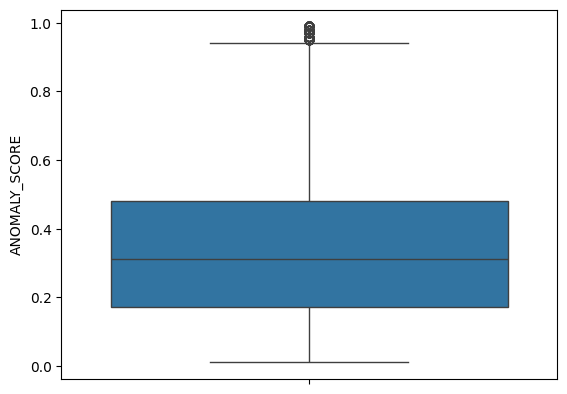

In [ ]:
import seaborn as sns
sns.boxplot(df['ANOMALY_SCORE'])

<Axes: ylabel='ANOMALY_SCORE'>

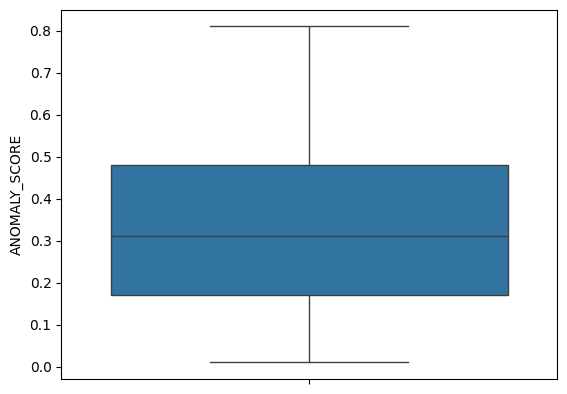

In [ ]:
low = df['ANOMALY_SCORE'].quantile(0.05)
up = df['ANOMALY_SCORE'].quantile(0.94)
df['ANOMALY_SCORE']=df['ANOMALY_SCORE'].clip(low,up)
sns.boxplot(df['ANOMALY_SCORE'])

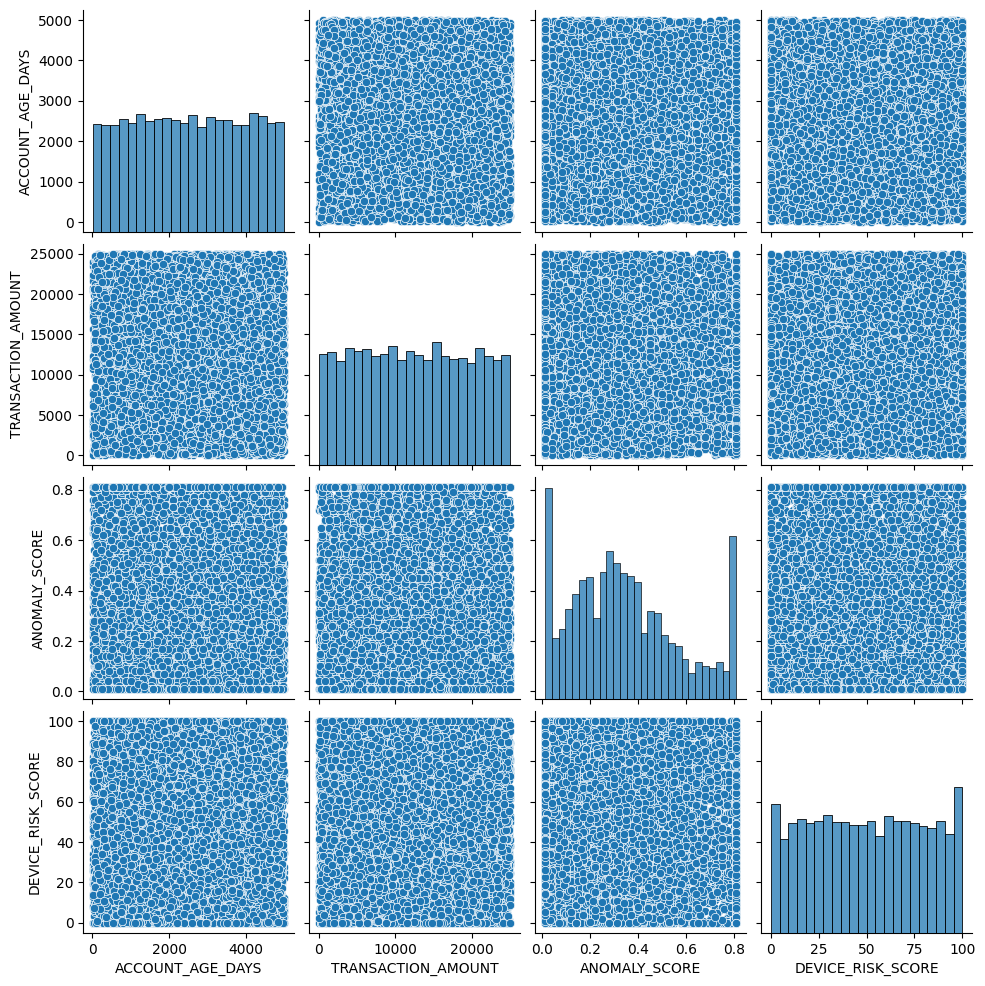

In [ ]:
sns.pairplot(df[['ACCOUNT_AGE_DAYS','TRANSACTION_AMOUNT',  'ANOMALY_SCORE', 'DEVICE_RISK_SCORE']])

In [ ]:
X=df.drop(df[['TRANSACTION_ID','FRAUD_FLAG']],axis=1)
y=df['FRAUD_FLAG']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier(criterion="entropy")
dc.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
y_pred=dc.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9265
[[1680   71]
 [  76  173]]
              precision    recall  f1-score   support

       False       0.96      0.96      0.96      1751
        True       0.71      0.69      0.70       249

    accuracy                           0.93      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.93      0.93      0.93      2000



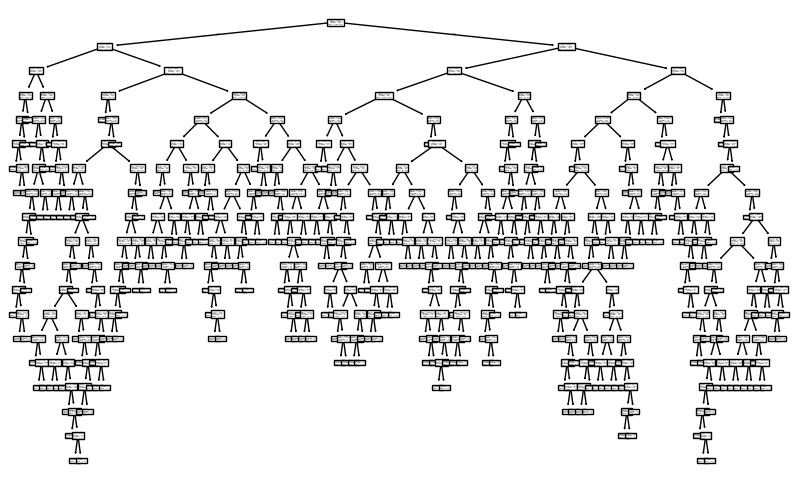

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
fig=plt.figure(figsize=(10,6))
tree.plot_tree(dc)
plt.show()

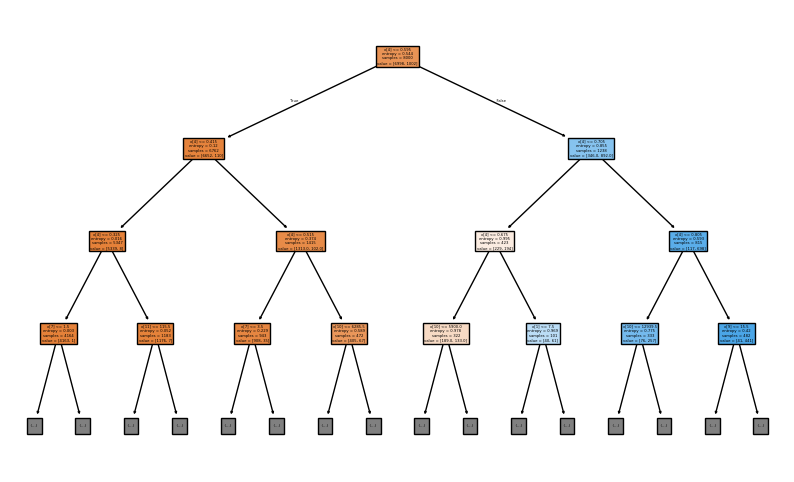

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
fig=plt.figure(figsize=(10,6))
tree.plot_tree(dc,max_depth=3,filled=True)
plt.show()